# HybridSN baseline：结构、训练、推理与分类图 / Reference-aligned workflow

本 Notebook 对齐参考 `HybridSN.ipynb` 的“加载数据 → 构造 patch → 定义网络 →
训练 → 测试指标 → 全图推理 → 分类图”主流程。默认模式不重复训练或再次使用测试集，
而是严格回放已经完成的 100 轮正式 baseline 运行；若需要新实验，使用文末给出的
统一命令行入口，确保 checkpoint、日志、性能与图表一次性归档。

固定口径：Pavia University、paper30/seed1442、训练 seed1442、PCA15、25×25 patch、
Adam(1e-3)、batch256、100 epochs、无数据增强、无 BatchNorm。


## 与参考 `HybridSN.ipynb` 的流程对应关系

| 参考流程 | 本 Notebook 对应内容 | 本项目改进 |
|---|---|---|
| `loadData/applyPCA/createImageCubes` | 第 1–2 节 | 直接复用冻结 `model_ready_dataset.npz`，不在测试数据上拟合 PCA |
| HybridSN 网络定义与 summary | 第 3 节 | 模型唯一实现位于 `src/models`，逐层 shape 断言 |
| 训练循环、loss 曲线 | 第 4–6、8 节 | 正式运行保留 100 轮历史、checkpoint 和环境指纹 |
| OA、AA、Kappa、逐类精度、混淆矩阵 | 第 7–9 节 | 统一测试一次，指标可由预测文件复核 |
| 遍历像元生成分类图 | 第 9 节 | 批量推理，并同时输出测试像元图和全部有标签像元图 |
| 结果保存 | 第 10 节 | PNG/CSV/JSON/Markdown 集中归档，便于实验报告和后续模型对比 |

参考代码中的 PCA20、11×11 patch、50/50 随机划分与本课程冻结 baseline 参数不同；
这里保持**流程高度一致**，但不改动已经确定的实验协议。


In [1]:
from __future__ import annotations

from datetime import datetime
from pathlib import Path
import inspect
import json
import sys

import matplotlib
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from torch import nn
from torch.utils.data import DataLoader
import yaml

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'pyproject.toml').is_file():
            return candidate
    raise FileNotFoundError('Cannot locate hsi_project/pyproject.toml')

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.datasets.高光谱预处理 import HSITensorDataset, PreprocessingConfig
from src.models.HybridSN模型 import HybridSN
from src.utils.reproducibility import seed_everything

print(f'项目根目录 / Project root: {PROJECT_ROOT}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')


项目根目录 / Project root: G:\高光谱智能图像解译\hsi_project
PyTorch: 2.12.1+cu130
CUDA available: True


## 1. 加载配置与模型就绪数据 / Load configuration and model-ready data

- **目的：** 从数据 Notebook 的冻结输出建立唯一实验输入。
- **输入：** 论文复现 YAML 和 `model_ready_dataset.npz`。
- **输出：** PCA15 立方体、坐标、原标签及固定 split 索引。
- **原理：** 模型阶段不读取原始 MAT，不拟合标准化/PCA，不重新生成 split。
- **验收：** 配置指纹、协议、seed、维度、dtype、样本数与索引覆盖全部一致。


In [2]:
CONFIG_PATH = PROJECT_ROOT / 'configs/模型训练/HybridSN_Pavia论文复现基线.yaml'
config_values = yaml.safe_load(CONFIG_PATH.read_text(encoding='utf-8'))
preprocessing_config = PreprocessingConfig.from_mapping(config_values)
MODEL_READY_PATH = (
    PROJECT_ROOT / 'data/processed' / preprocessing_config.dataset_name
    / preprocessing_config.route_name() / 'model_ready_dataset.npz'
)
if not MODEL_READY_PATH.is_file():
    raise FileNotFoundError(
        f'{MODEL_READY_PATH} does not exist. Run the data preprocessing notebook first.'
    )

with np.load(MODEL_READY_PATH, allow_pickle=False) as saved:
    artifact = {name: saved[name].copy() for name in saved.files}

assert str(artifact['schema_version'].item()) == '1.0'
assert str(artifact['dataset_name'].item()) == 'pavia_university'
assert str(artifact['split_protocol'].item()) == 'paper30'
assert int(artifact['split_seed'].item()) == 1442
assert str(artifact['config_fingerprint'].item()) == preprocessing_config.fingerprint()
assert artifact['transformed_cube'].shape == (610, 340, 15)
assert artifact['transformed_cube'].dtype == np.float32
assert artifact['coordinates'].shape == (42776, 2)
assert artifact['raw_labels'].shape == (42776,)
assert int(artifact['patch_size'].item()) == 25
assert int(artifact['num_classes'].item()) == 9
assert artifact['train_indices'].size == 12832
assert artifact['validation_indices'].size == 0
assert artifact['test_indices'].size == 29944
assigned = np.concatenate([
    artifact['train_indices'],
    artifact['validation_indices'],
    artifact['test_indices'],
])
assert np.array_equal(np.sort(assigned), np.arange(42776))
assert np.unique(assigned).size == assigned.size

print(f'模型就绪数据 / Model-ready data: {MODEL_READY_PATH}')
print(f"Cube: {artifact['transformed_cube'].shape} {artifact['transformed_cube'].dtype}")
print('Samples: train=12,832, validation=0, test=29,944')


模型就绪数据 / Model-ready data: G:\高光谱智能图像解译\hsi_project\data\processed\pavia_university\paper30__seed1442__standard_pca15_patch25\model_ready_dataset.npz
Cube: (610, 340, 15) float32
Samples: train=12,832, validation=0, test=29,944


## 2. 构造 Dataset 与 DataLoader / Build Dataset and DataLoader

patch 在取样时由已保存的 PCA15 立方体动态生成。这样既符合论文的中心像元监督方式，又不会在磁盘保存大量重复邻域。


In [3]:
BATCH_SIZE = int(config_values['training']['batch_size'])
LOADER_SEED = int(config_values['experiment']['seed'])
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

def make_dataset(indices: np.ndarray):
    if indices.size == 0:
        return None
    return HSITensorDataset(
        artifact['transformed_cube'],
        artifact['coordinates'],
        artifact['raw_labels'],
        indices,
        representation='patch',
        patch_size=25,
        padding_mode=str(artifact['padding_mode'].item()),
        padding_value=float(artifact['padding_value'].item()),
    )

datasets = {
    'train': make_dataset(artifact['train_indices']),
    'validation': make_dataset(artifact['validation_indices']),
    'test': make_dataset(artifact['test_indices']),
}
train_generator = torch.Generator().manual_seed(LOADER_SEED)
loaders = {
    name: None if dataset is None else DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=name == 'train',
        generator=train_generator if name == 'train' else None,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )
    for name, dataset in datasets.items()
}
print({name: None if loader is None else len(loader) for name, loader in loaders.items()})


{'train': 51, 'validation': None, 'test': 117}


In [4]:
sample = datasets['train'][0]
assert sample['input'].shape == (1, 15, 25, 25)
assert sample['input'].dtype == torch.float32
assert sample['label'].dtype == torch.int64
assert 0 <= int(sample['label']) <= 8
print({name: tuple(value.shape) for name, value in sample.items()})


{'input': (1, 15, 25, 25), 'label': (), 'raw_label': (), 'coordinate': (2,), 'sample_index': ()}


## 3. 定义并核对论文 HybridSN / Define and verify HybridSN

核心类保存在 `src/models/HybridSN模型.py`，这里导入而不复制，确保 Notebook、测试和后续训练共用同一模型。

逐层尺寸：

```text
N×1×15×25×25
→ N×8×9×23×23
→ N×16×5×21×21
→ N×32×3×19×19
→ N×96×19×19
→ N×64×17×17
→ N×18496 → N×256 → N×128 → N×9 logits
```


In [5]:
# 显示实际执行的唯一模型定义，而不是在 Notebook 中维护副本。
print(inspect.getsource(HybridSN))

model = HybridSN(
    num_classes=int(config_values['model']['num_classes']),
    dropout=float(config_values['model']['dropout']),
)
trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
assert trainable_parameters == 4_844_793
assert not any(isinstance(module, nn.Softmax) for module in model.modules())
assert not any(isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)) for module in model.modules())
print(model)
print(f'Trainable parameters: {trainable_parameters:,}')


class HybridSN(nn.Module):
    """论文 HybridSN 在 Pavia University 上的 PyTorch 基线实现。

    该模型严格使用固定的 PCA15、25 x 25 patch 和九分类接口。输出为未经
    Softmax 的 logits，以便直接交给 ``torch.nn.CrossEntropyLoss``。

    Parameters
    ----------
    num_classes:
        输出类别数。首个 Pavia University 基线固定为 9。
    dropout:
        两个全连接隐藏层之后的 Dropout 概率。论文实现使用 0.4。
    """

    INPUT_CHANNELS = 1
    INPUT_BANDS = 15
    PATCH_SIZE = 25
    NUM_CLASSES = 9
    RESHAPED_CHANNELS = 32 * 3
    FLATTENED_FEATURES = 64 * 17 * 17

    def __init__(self, *, num_classes: int = NUM_CLASSES, dropout: float = 0.4) -> None:
        super().__init__()
        if num_classes != self.NUM_CLASSES:
            raise ValueError(
                "the first Pavia University HybridSN baseline requires num_classes=9"
            )
        if not 0.0 <= dropout < 1.0:
            raise ValueError("dropout must satisfy 0 <= dropout < 1")

        # PyTorch Conv3d uses N x C x D x H x W. All convolutions use the
        # paper's stride=1 a

In [6]:
feature_shapes = {}
handles = []
for name in ('conv3d_1', 'conv3d_2', 'conv3d_3', 'conv2d', 'fc1', 'fc2', 'classifier'):
    layer = getattr(model, name)
    handles.append(layer.register_forward_hook(
        lambda _module, _inputs, output, layer_name=name: feature_shapes.__setitem__(
            layer_name, tuple(output.shape)
        )
    ))
model.eval()
with torch.inference_mode():
    dummy_logits = model(torch.zeros(2, 1, 15, 25, 25))
for handle in handles:
    handle.remove()

expected_shapes = {
    'conv3d_1': (2, 8, 9, 23, 23),
    'conv3d_2': (2, 16, 5, 21, 21),
    'conv3d_3': (2, 32, 3, 19, 19),
    'conv2d': (2, 64, 17, 17),
    'fc1': (2, 256),
    'fc2': (2, 128),
    'classifier': (2, 9),
}
assert feature_shapes == expected_shapes
assert dummy_logits.shape == (2, 9)
print({'input': (2, 1, 15, 25, 25), **feature_shapes})
print('reshape:', (2, 96, 19, 19), 'flatten:', (2, 18496))


{'input': (2, 1, 15, 25, 25), 'conv3d_1': (2, 8, 9, 23, 23), 'conv3d_2': (2, 16, 5, 21, 21), 'conv3d_3': (2, 32, 3, 19, 19), 'conv2d': (2, 64, 17, 17), 'fc1': (2, 256), 'fc2': (2, 128), 'classifier': (2, 9)}
reshape: (2, 96, 19, 19) flatten: (2, 18496)


## 4. 损失、优化器与复现设置 / Loss, optimizer and reproducibility

交叉熵直接接收 logits，因此模型内部不能再添加 Softmax。初始化使用作者 Keras 模型默认的 Glorot/Xavier 均匀分布。


In [7]:
TRAINING_SEED = int(config_values['experiment']['seed'])
LEARNING_RATE = float(config_values['training']['learning_rate'])
WEIGHT_DECAY = float(config_values['training']['weight_decay'])
EPOCHS = int(config_values['training']['epochs'])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

seed_everything(TRAINING_SEED)
model = HybridSN(
    num_classes=int(config_values['model']['num_classes']),
    dropout=float(config_values['model']['dropout']),
).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
print(f'Device: {DEVICE}; Adam lr={LEARNING_RATE}; epochs={EPOCHS}')


Device: cuda; Adam lr=0.001; epochs=100


## 5. 训练与验证函数 / Training and validation functions

- 训练阶段启用 Dropout 并执行反向传播；
- 验证和测试阶段使用 `model.eval()` 与 `torch.inference_mode()`；
- `paper30` 的验证集为空，不能用测试集替代验证集选择 epoch；
- 若以后使用 `fair24_6_70`，必须先由数据 Notebook 导出与其独立冻结状态匹配的模型就绪数据。


In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum = 0.0
    correct = 0
    sample_count = 0
    for batch in loader:
        inputs = batch['input'].to(device, non_blocking=PIN_MEMORY)
        labels = batch['label'].to(device, non_blocking=PIN_MEMORY)
        optimizer.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        batch_size = labels.size(0)
        loss_sum += float(loss.detach()) * batch_size
        correct += int((logits.argmax(dim=1) == labels).sum())
        sample_count += batch_size
    return {
        'loss': loss_sum / sample_count,
        'accuracy': correct / sample_count,
        'samples': sample_count,
    }

@torch.inference_mode()
def evaluate_loader(model, loader, criterion, device):
    if loader is None:
        raise ValueError('the selected protocol has no validation loader')
    model.eval()
    loss_sum = 0.0
    labels_all = []
    predictions_all = []
    sample_indices_all = []
    for batch in loader:
        inputs = batch['input'].to(device, non_blocking=PIN_MEMORY)
        labels = batch['label'].to(device, non_blocking=PIN_MEMORY)
        logits = model(inputs)
        loss_sum += float(criterion(logits, labels)) * labels.size(0)
        labels_all.append(labels.cpu().numpy())
        predictions_all.append(logits.argmax(dim=1).cpu().numpy())
        sample_indices_all.append(batch['sample_index'].numpy())
    labels_np = np.concatenate(labels_all)
    predictions_np = np.concatenate(predictions_all)
    sample_indices_np = np.concatenate(sample_indices_all)
    return {
        'loss': loss_sum / labels_np.size,
        'accuracy': float(accuracy_score(labels_np, predictions_np)),
        'labels': labels_np,
        'predictions': predictions_np,
        'sample_indices': sample_indices_np,
    }


In [9]:
def fit_hybridsn(
    model, train_loader, validation_loader, criterion, optimizer, device, epochs, output_dir
):
    output_dir.mkdir(parents=True, exist_ok=False)
    history = []
    best_validation_accuracy = -np.inf
    best_checkpoint = None
    for epoch in range(1, epochs + 1):
        train_stats = train_one_epoch(model, train_loader, criterion, optimizer, device)
        record = {
            'epoch': epoch,
            'train_loss': train_stats['loss'],
            'train_accuracy': train_stats['accuracy'],
        }
        if validation_loader is not None:
            validation_stats = evaluate_loader(model, validation_loader, criterion, device)
            record.update({
                'validation_loss': validation_stats['loss'],
                'validation_accuracy': validation_stats['accuracy'],
            })
            if validation_stats['accuracy'] > best_validation_accuracy:
                best_validation_accuracy = validation_stats['accuracy']
                best_checkpoint = output_dir / 'checkpoint_best.pt'
                torch.save({'epoch': epoch, 'model_state_dict': model.state_dict()}, best_checkpoint)
        history.append(record)
        message = (
            f"epoch={epoch:03d}/{epochs} train_loss={record['train_loss']:.6f} "
            f"train_acc={record['train_accuracy']:.4f}"
        )
        if validation_loader is not None:
            message += (
                f" val_loss={record['validation_loss']:.6f} "
                f"val_acc={record['validation_accuracy']:.4f}"
            )
        print(message)

    final_checkpoint = output_dir / 'checkpoint_final.pt'
    torch.save(
        {
            'epoch': epochs,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'config': config_values,
            'preprocessing_fingerprint': str(artifact['config_fingerprint'].item()),
            'history': history,
            'test_set_evaluated': False,
        },
        final_checkpoint,
    )
    (output_dir / 'history.json').write_text(
        json.dumps(history, indent=2, ensure_ascii=False) + '\n', encoding='utf-8'
    )
    selected_checkpoint = best_checkpoint or final_checkpoint
    return history, selected_checkpoint


## 6. 正式训练开关 / Formal training gate

默认保持 `False`。在运行前先确认 GPU、配置、参数量和数据指纹。`paper30` 没有验证集，因此选用固定第 100 epoch，而不是测试集最优 epoch。


In [10]:
RUN_TRAINING = False
history = None
selected_checkpoint = None

if RUN_TRAINING:
    run_name = (
        f"pavia_university__hybridsn__seed{TRAINING_SEED}__"
        f"{datetime.now().strftime('%Y%m%d-%H%M')}"
    )
    output_dir = PROJECT_ROOT / 'experiments' / run_name
    history, selected_checkpoint = fit_hybridsn(
        model,
        loaders['train'],
        loaders['validation'],
        criterion,
        optimizer,
        DEVICE,
        EPOCHS,
        output_dir,
    )
    print(f'Selected checkpoint: {selected_checkpoint}')
else:
    print('正式训练未启动 / Formal training is disabled.')


正式训练未启动 / Formal training is disabled.


In [11]:
if history:
    epochs_axis = [record['epoch'] for record in history]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs_axis, [record['train_loss'] for record in history], label='train')
    axes[1].plot(epochs_axis, [record['train_accuracy'] for record in history], label='train')
    if 'validation_loss' in history[0]:
        axes[0].plot(epochs_axis, [record['validation_loss'] for record in history], label='validation')
        axes[1].plot(epochs_axis, [record['validation_accuracy'] for record in history], label='validation')
    axes[0].set_title('Loss')
    axes[1].set_title('Accuracy')
    for axis in axes:
        axis.set_xlabel('Epoch')
        axis.legend()
        axis.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print('无训练历史可绘制 / No training history to plot.')


无训练历史可绘制 / No training history to plot.


## 7. 最终测试与指标 / Final test and metrics

测试开关与训练开关分离。只有模型结构、训练策略和 checkpoint 已冻结后，才允许把 `RUN_FINAL_TEST` 改为 `True`。输出 OA、AA、Kappa、逐类准确率与混淆矩阵。


In [12]:
def summarize_classification(labels, predictions, num_classes=9):
    matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
    class_totals = matrix.sum(axis=1)
    per_class = np.divide(
        np.diag(matrix),
        class_totals,
        out=np.zeros(num_classes, dtype=np.float64),
        where=class_totals != 0,
    )
    return {
        'oa': float(accuracy_score(labels, predictions)),
        'aa': float(per_class.mean()),
        'kappa': float(cohen_kappa_score(labels, predictions)),
        'per_class_accuracy': per_class,
        'confusion_matrix': matrix,
    }

RUN_FINAL_TEST = False
test_summary = None
if RUN_FINAL_TEST:
    if selected_checkpoint is None or not Path(selected_checkpoint).is_file():
        raise FileNotFoundError('freeze or select a checkpoint before final test')
    checkpoint = torch.load(selected_checkpoint, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    test_output = evaluate_loader(model, loaders['test'], criterion, DEVICE)
    test_summary = summarize_classification(
        test_output['labels'], test_output['predictions'], num_classes=9
    )
    print({key: value for key, value in test_summary.items() if key not in {'confusion_matrix', 'per_class_accuracy'}})
    print('Per-class accuracy:', test_summary['per_class_accuracy'])
    sns.heatmap(test_summary['confusion_matrix'], annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted class')
    plt.ylabel('True class')
    plt.title('HybridSN test confusion matrix')
    plt.tight_layout()
    plt.show()
else:
    print('本单元不重新评估测试集；第 8 节只读回放已冻结正式结果。')


本单元不重新评估测试集；第 8 节只读回放已冻结正式结果。


## 8. 正式 100 轮实验结果回放 / Replay the completed formal run

本节默认加载已经生成并冻结的正式运行，不重新训练，也不重新推理测试集。
它会核对运行目录必须包含 checkpoint、预测、指标、性能和分类图，并验证
预处理指纹与当前 `model_ready_dataset.npz` 一致。


In [13]:
# 自动优先选择指定正式运行；只有文件完整、已正式测试的运行才允许回放。
import pandas as pd
import shutil
from IPython.display import Image, display

PREFERRED_FORMAL_RUN = (
    PROJECT_ROOT / 'experiments/pavia_university__hybridsn__seed1442__latest'
)
required_formal_files = {
    'checkpoint_final.pt', 'history.csv', 'metrics.json', 'performance.json',
    'predictions_test.npz', 'classification_maps.npz', 'loss_curve.png',
    'confusion_matrix.png', 'per_class_accuracy.png', 'classification_map.png',
    'spatial_overlap_audit.json', 'environment.json', '实验记录.md',
}

def is_complete_formal_run(path: Path) -> bool:
    if not path.is_dir() or any(not (path / name).is_file() for name in required_formal_files):
        return False
    candidate_metrics = json.loads((path / 'metrics.json').read_text(encoding='utf-8'))
    candidate_performance = json.loads((path / 'performance.json').read_text(encoding='utf-8'))
    return (
        candidate_metrics.get('test_set_used_for_model_selection') is False
        and candidate_performance.get('formal_test_evaluated') is True
        and candidate_performance.get('training', {}).get('epochs') == 100
    )

candidates = [PREFERRED_FORMAL_RUN] + sorted(
    (PROJECT_ROOT / 'experiments').glob('pavia_university__hybridsn__seed1442__*'),
    reverse=True,
)
FORMAL_RUN = next((path for path in candidates if is_complete_formal_run(path)), None)
if FORMAL_RUN is None:
    raise FileNotFoundError('No complete 100-epoch HybridSN formal run was found.')

metrics = json.loads((FORMAL_RUN / 'metrics.json').read_text(encoding='utf-8'))
performance = json.loads((FORMAL_RUN / 'performance.json').read_text(encoding='utf-8'))
spatial_audit = json.loads((FORMAL_RUN / 'spatial_overlap_audit.json').read_text(encoding='utf-8'))
environment = json.loads((FORMAL_RUN / 'environment.json').read_text(encoding='utf-8'))
history_df = pd.read_csv(FORMAL_RUN / 'history.csv', encoding='utf-8-sig')

assert len(history_df) == 100 and int(history_df['epoch'].iloc[-1]) == 100
assert metrics['test_samples'] == artifact['test_indices'].size == 29944
assert metrics['preprocessing_fingerprint'] == str(artifact['config_fingerprint'].item())
assert environment['selected_device'] == 'cuda'

headline_metrics = pd.DataFrame([
    {'指标': 'OA', '数值': metrics['oa'], '报告值': f"{metrics['oa']:.4%}"},
    {'指标': 'AA', '数值': metrics['aa'], '报告值': f"{metrics['aa']:.4%}"},
    {'指标': 'Kappa', '数值': metrics['kappa'], '报告值': f"{metrics['kappa']:.6f}"},
    {'指标': 'Test loss', '数值': metrics['test_loss'], '报告值': f"{metrics['test_loss']:.8f}"},
    {'指标': 'Test samples', '数值': metrics['test_samples'], '报告值': f"{metrics['test_samples']:,}"},
])
display(headline_metrics)
print(f'正式运行目录 / Formal run: {FORMAL_RUN.relative_to(PROJECT_ROOT)}')
print(f"Checkpoint: {metrics['checkpoint']} ({metrics['checkpoint_sha256'][:12]}...)")


,指标,数值,报告值
0,OA,0.999532,99.9532%
1,AA,0.998789,99.8789%
2,Kappa,0.999380,0.999380
3,Test loss,0.004360,0.00436014
4,Test samples,29944.000000,"29,944"


正式运行目录 / Formal run: experiments\pavia_university__hybridsn__seed1442__20260817-1251
Checkpoint: checkpoint_final.pt (3edac8d7a7f0...)


## 9. 训练曲线、混淆矩阵、逐类精度与分类图

以下图像来自同一正式运行目录。分类图依次给出 Ground Truth、仅测试像元预测、
全部有标签像元预测；背景保持黑色，因此不会把未标注区域伪装成分类结果。


,class_index,raw_label,class_name_zh,class_name,support,accuracy,accuracy_percent
0,0,1,沥青路面,Asphalt,4642,0.99956915,99.9569%
1,1,2,草地,Meadows,13055,1.00000000,100.0000%
2,2,3,砾石,Gravel,1469,0.99795779,99.7958%
3,3,4,树木,Trees,2145,0.99906760,99.9068%
4,4,5,涂漆金属板,Painted metal sheets,942,0.99787686,99.7877%
5,5,6,裸土,Bare Soil,3520,1.00000000,100.0000%
6,6,7,沥青材料,Bitumen,931,0.99462943,99.4629%
7,7,8,自锁砖,Self-Blocking Bricks,2577,1.00000000,100.0000%
8,8,9,阴影,Shadows,663,1.00000000,100.0000%



训练损失曲线 / Loss curve


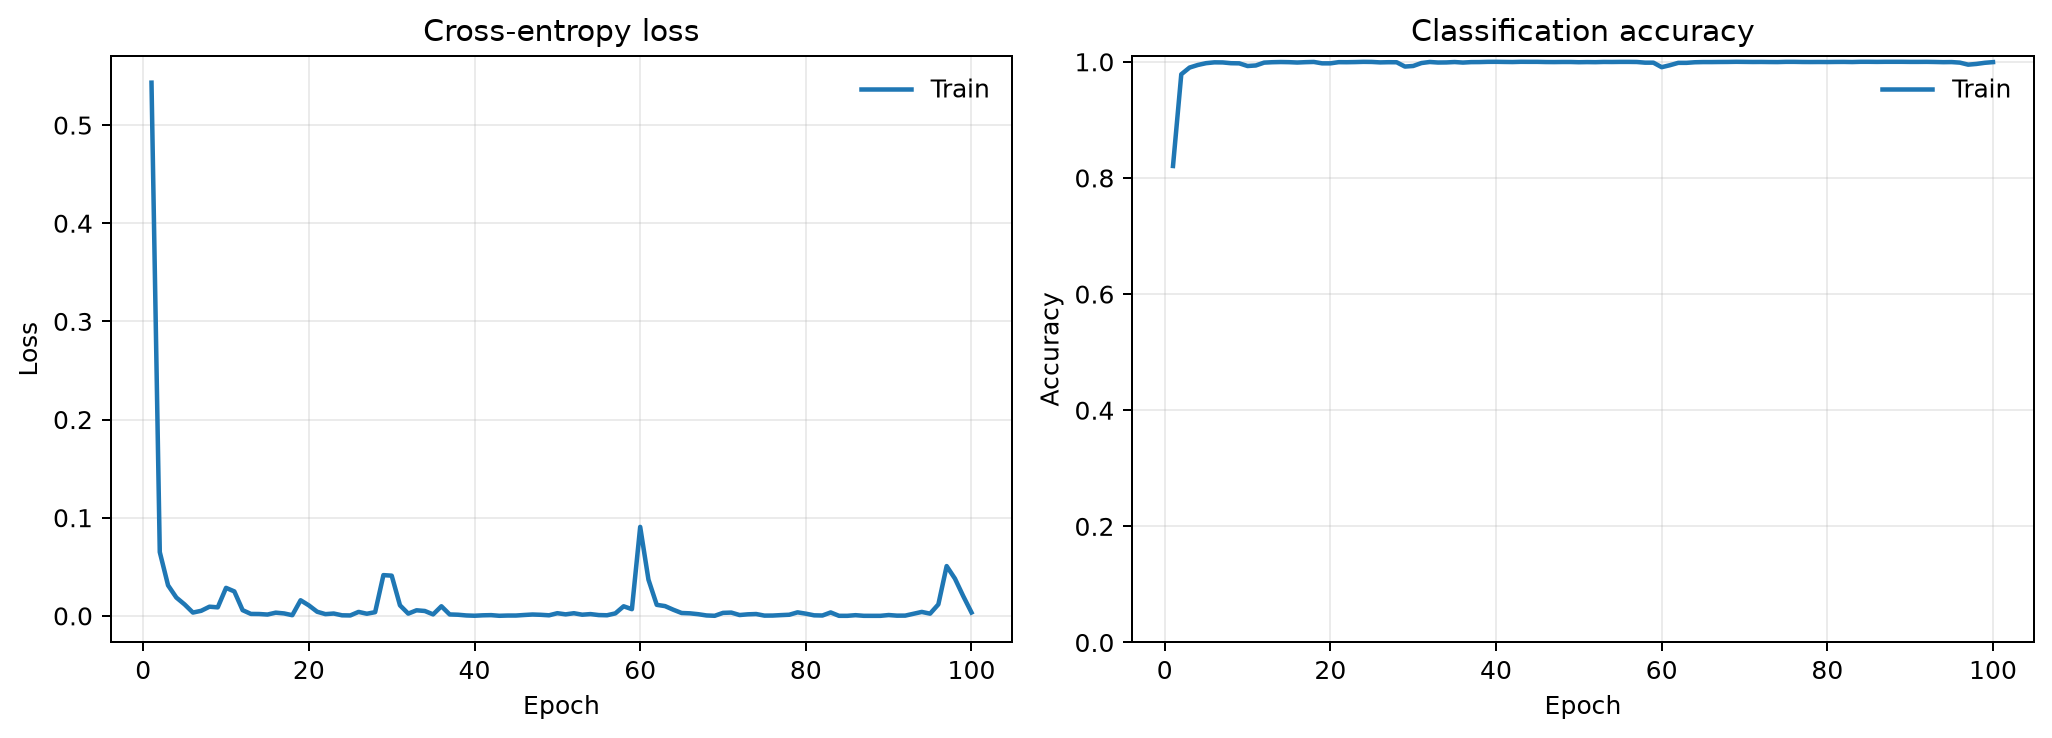


测试混淆矩阵 / Confusion matrix


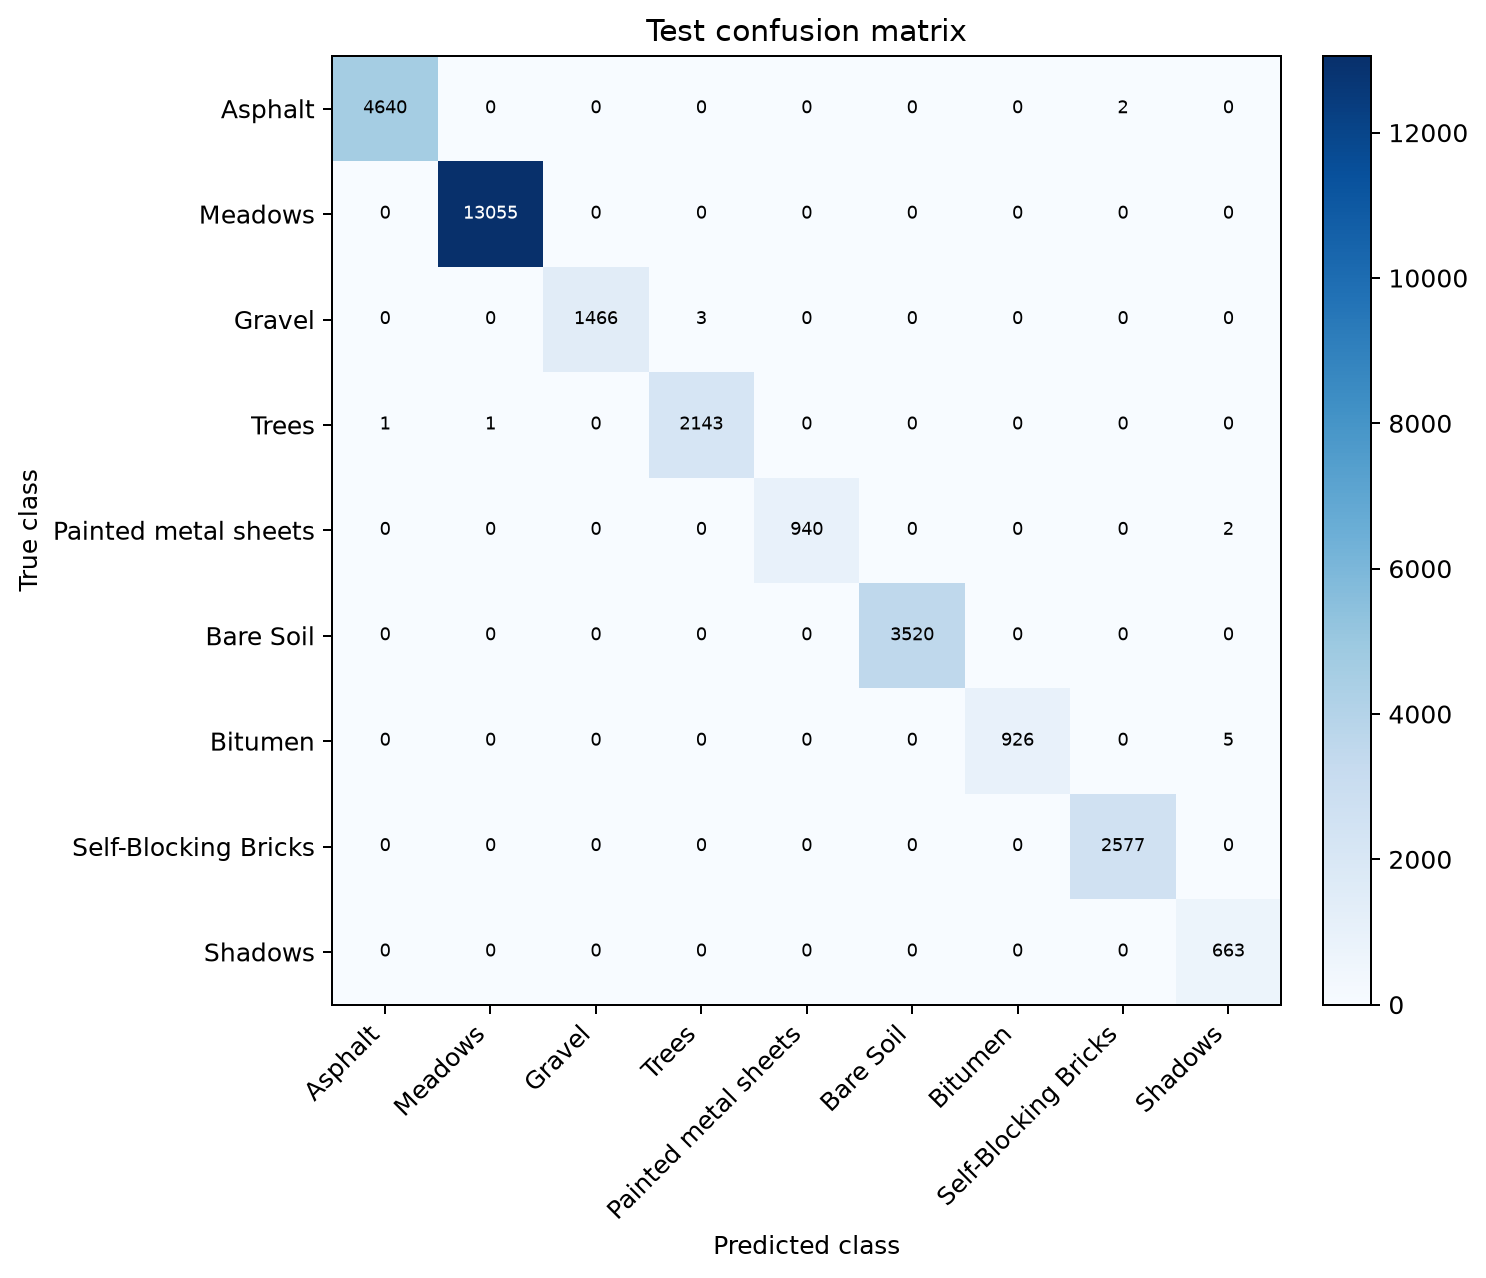


逐类精度 / Per-class accuracy


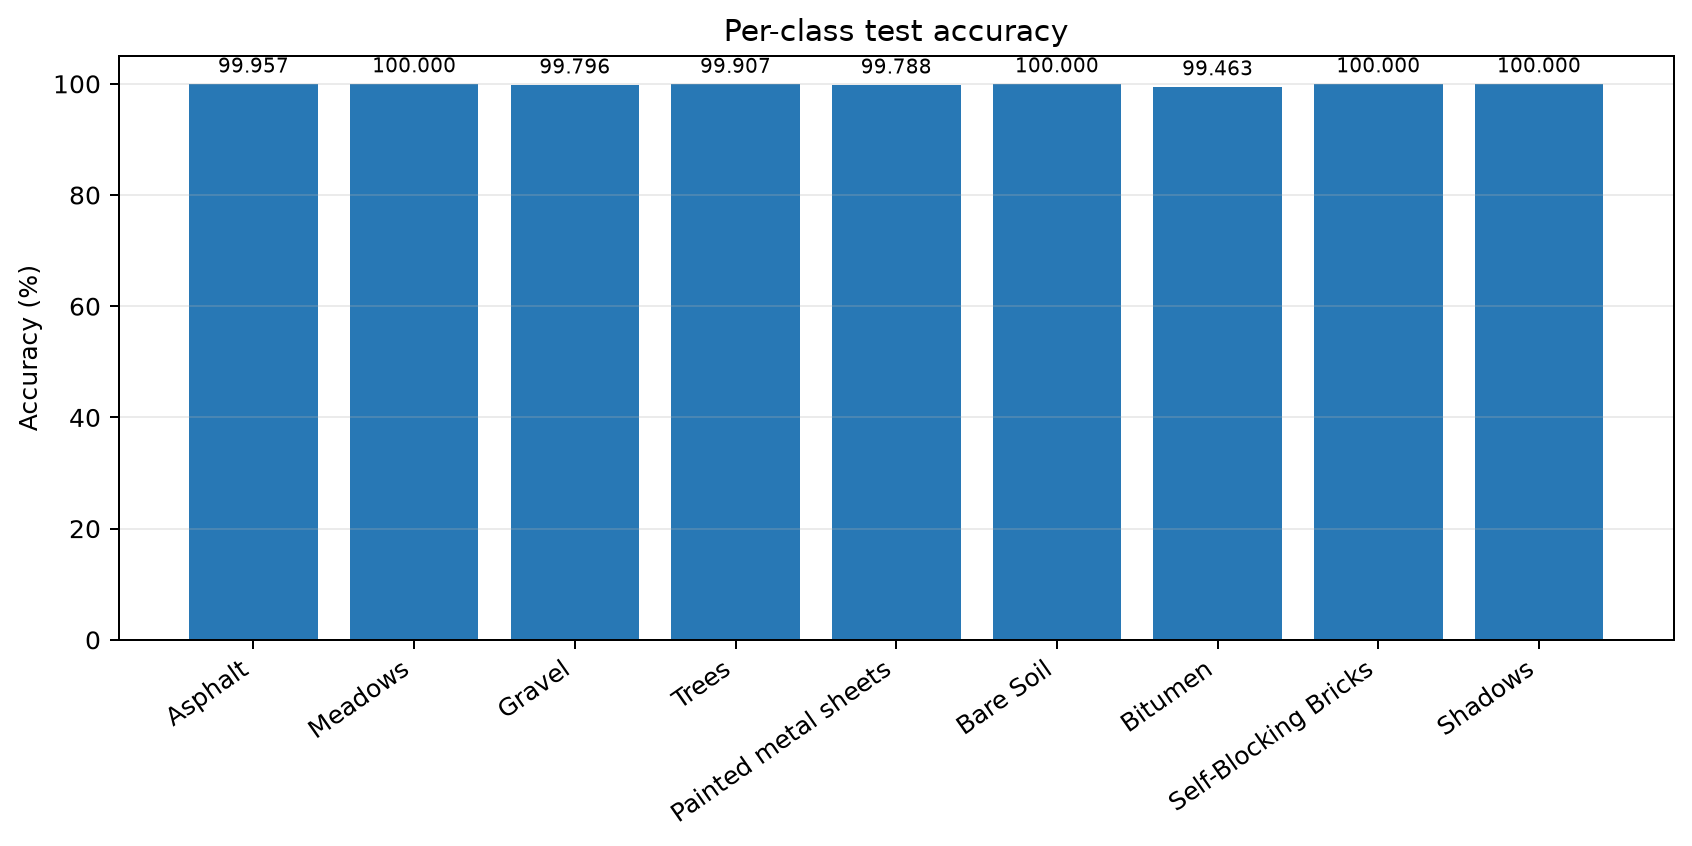


分类结果图 / Classification maps


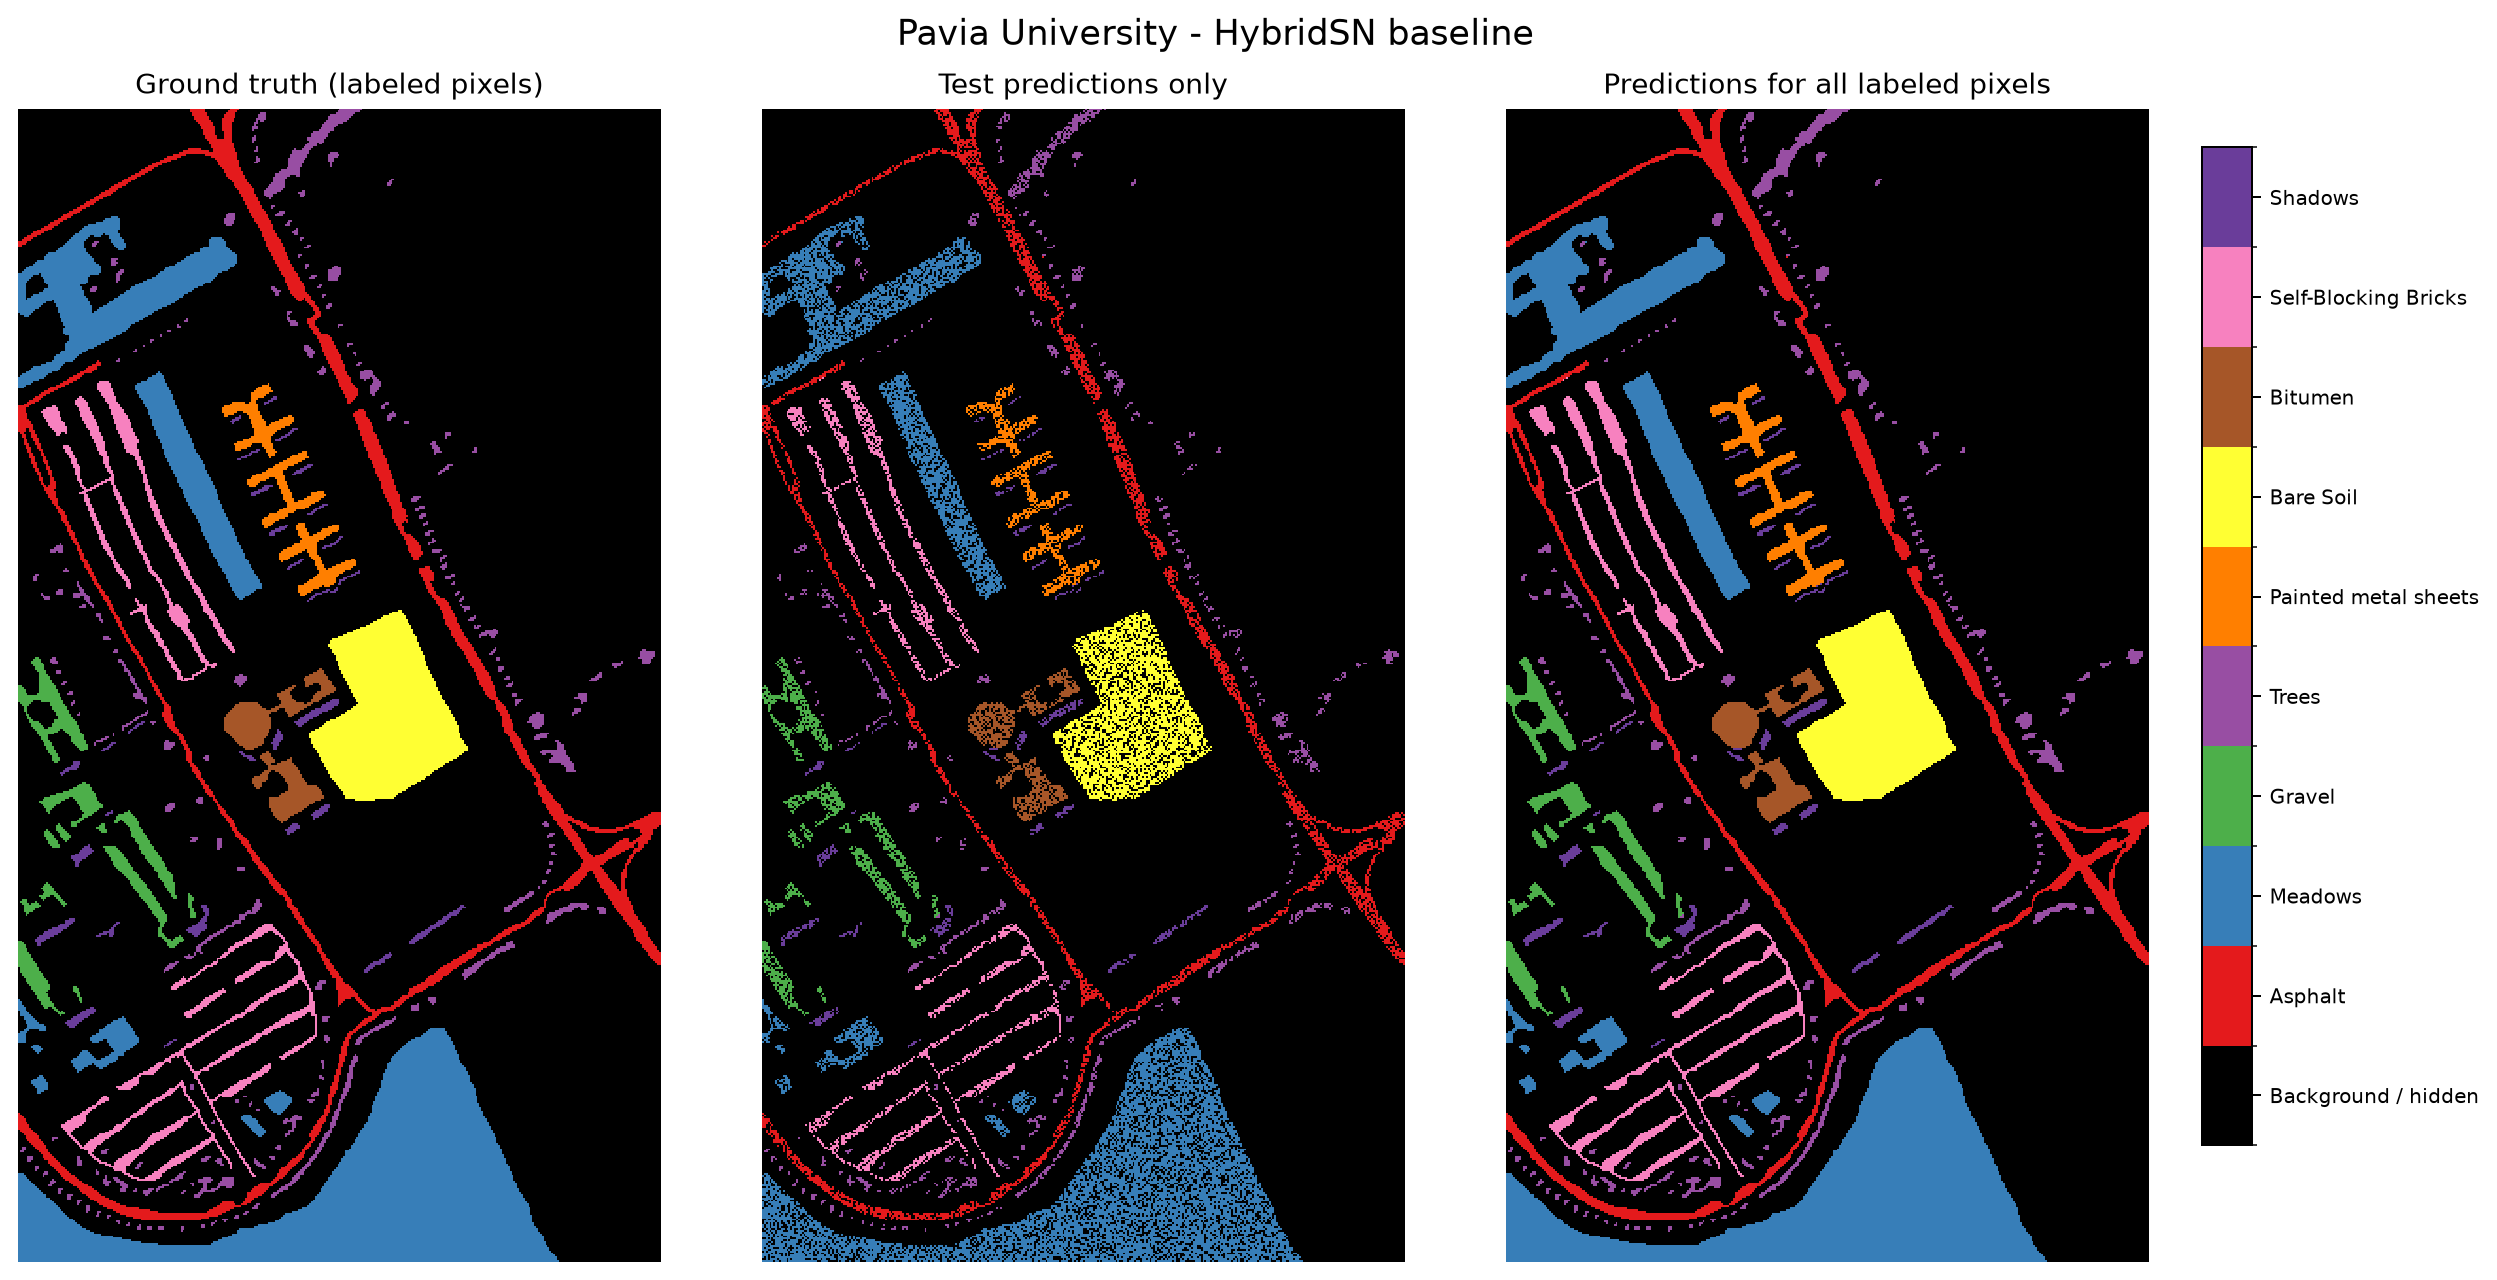

In [14]:
# 逐类结果表；类别索引在模型内部是 0–8，报告使用原始标签 1–9。
PAVIA_CLASS_NAMES_ZH = (
    '沥青路面', '草地', '砾石', '树木', '涂漆金属板',
    '裸土', '沥青材料', '自锁砖', '阴影',
)
per_class_table = pd.DataFrame(metrics['per_class'])
per_class_table.insert(2, 'class_name_zh', PAVIA_CLASS_NAMES_ZH)
per_class_table['accuracy_percent'] = per_class_table['accuracy'] * 100
display(per_class_table.style.format({
    'accuracy': '{:.8f}',
    'accuracy_percent': '{:.4f}%',
}))

figure_files = (
    ('训练损失曲线 / Loss curve', 'loss_curve.png'),
    ('测试混淆矩阵 / Confusion matrix', 'confusion_matrix.png'),
    ('逐类精度 / Per-class accuracy', 'per_class_accuracy.png'),
    ('分类结果图 / Classification maps', 'classification_map.png'),
)
for title, filename in figure_files:
    print(f'\n{title}')
    display(Image(filename=str(FORMAL_RUN / filename), width=1150))


In [15]:
# 从独立保存的测试预测重新计算错误像元，证明指标可审计而非只依赖 PNG。
with np.load(FORMAL_RUN / 'predictions_test.npz', allow_pickle=False) as prediction_file:
    labels_test = prediction_file['labels'].astype(np.int64)
    predictions_test = prediction_file['predictions'].astype(np.int64)
    coordinates_test = prediction_file['coordinates'].astype(np.int64)

wrong_positions = np.flatnonzero(labels_test != predictions_test)
misclassified_rows = []
for position in wrong_positions:
    true_index = int(labels_test[position])
    predicted_index = int(predictions_test[position])
    row, column = map(int, coordinates_test[position])
    misclassified_rows.append({
        'row': row,
        'column': column,
        'true_raw_label': true_index + 1,
        'true_class': PAVIA_CLASS_NAMES_ZH[true_index],
        'predicted_raw_label': predicted_index + 1,
        'predicted_class': PAVIA_CLASS_NAMES_ZH[predicted_index],
    })
misclassified_table = pd.DataFrame(misclassified_rows)
assert len(misclassified_table) == int(metrics['test_samples'] - np.trace(np.asarray(metrics['confusion_matrix'])))
assert np.isclose(np.mean(labels_test == predictions_test), metrics['oa'])
print(f'测试集错误像元 / Misclassified test pixels: {len(misclassified_table)} / {len(labels_test):,}')
display(misclassified_table)


测试集错误像元 / Misclassified test pixels: 14 / 29,944


,row,column,true_raw_label,true_class,predicted_raw_label,predicted_class
0,70,42,4,树木,2,草地
1,78,148,4,树木,1,沥青路面
2,142,32,1,沥青路面,8,自锁砖
3,143,30,1,沥青路面,8,自锁砖
4,251,166,5,涂漆金属板,9,阴影
5,252,164,5,涂漆金属板,9,阴影
6,338,120,7,沥青材料,9,阴影
7,338,121,7,沥青材料,9,阴影
8,338,122,7,沥青材料,9,阴影
9,338,123,7,沥青材料,9,阴影


## 10. 性能记录、解释边界与后续对比基线

性能同时报告端到端测试推理（含 DataLoader/patch 提取）和纯模型吞吐，两者不可混写。
此外，`paper30` 是随机像元划分而非空间分区划分；25×25 邻域会在空间上重叠，
因此极高精度只代表当前协议下的 baseline，不等价于跨区域泛化能力。


In [16]:
# 将速度、显存和空间重叠审计整理成可直接进入报告的表格。
training_perf = performance['training']
test_perf = performance['test_inference']
compute_perf = performance['model_compute_benchmark']

performance_table = pd.DataFrame([
    {'项目': '可训练参数', '数值': performance['model']['trainable_parameters'], '单位': 'parameters'},
    {'项目': '100轮训练总耗时', '数值': training_perf['total_seconds'], '单位': 's'},
    {'项目': '平均每轮耗时', '数值': training_perf['mean_epoch_seconds'], '单位': 's/epoch'},
    {'项目': '训练峰值显存 allocated', '数值': training_perf['peak_memory_allocated_bytes'] / 1024**2, '单位': 'MiB'},
    {'项目': '端到端测试耗时', '数值': test_perf['elapsed_seconds'], '单位': 's'},
    {'项目': '端到端测试吞吐', '数值': test_perf['throughput_samples_per_second'], '单位': 'samples/s'},
    {'项目': '纯模型 batch256 延迟', '数值': compute_perf['milliseconds_per_batch'], '单位': 'ms/batch'},
    {'项目': '纯模型吞吐', '数值': compute_perf['throughput_samples_per_second'], '单位': 'samples/s'},
])
display(performance_table.style.format({'数值': '{:,.4f}'}))

overlap_table = pd.DataFrame([
    {
        '审计项': '测试 patch 内至少一个训练中心',
        '比例': spatial_audit['any_training_center_in_query_patch']['fraction_with_at_least_one'],
        '中位数/patch': spatial_audit['any_training_center_in_query_patch']['median'],
        '均值/patch': spatial_audit['any_training_center_in_query_patch']['mean'],
    },
    {
        '审计项': '测试 patch 内至少一个同类训练中心',
        '比例': spatial_audit['same_class_training_center_in_query_patch']['fraction_with_at_least_one'],
        '中位数/patch': spatial_audit['same_class_training_center_in_query_patch']['median'],
        '均值/patch': spatial_audit['same_class_training_center_in_query_patch']['mean'],
    },
])
display(overlap_table.style.format({'比例': '{:.4%}', '中位数/patch': '{:.2f}', '均值/patch': '{:.2f}'}))

comparison_baseline = pd.DataFrame([{
    'method': 'HybridSN baseline',
    'reducer': 'PCA15',
    'patch_size': 25,
    'split_protocol': 'paper30',
    'split_seed': 1442,
    'training_seed': 1442,
    'epochs': training_perf['epochs'],
    'parameters': performance['model']['trainable_parameters'],
    'oa': metrics['oa'],
    'aa': metrics['aa'],
    'kappa': metrics['kappa'],
    'test_inference_seconds': test_perf['elapsed_seconds'],
    'test_throughput_samples_per_second': test_perf['throughput_samples_per_second'],
}])
display(comparison_baseline)


,项目,数值,单位
0,可训练参数,"4,844,793.0000",parameters
1,100轮训练总耗时,494.3586,s
2,平均每轮耗时,4.9313,s/epoch
3,训练峰值显存 allocated,363.0205,MiB
4,端到端测试耗时,2.3592,s
5,端到端测试吞吐,"12,692.4161",samples/s
6,纯模型 batch256 延迟,7.0402,ms/batch
7,纯模型吞吐,"36,362.4484",samples/s


,审计项,比例,中位数/patch,均值/patch
0,测试 patch 内至少一个训练中心,100.0000%,92.00,100.56
1,测试 patch 内至少一个同类训练中心,100.0000%,89.00,96.27


,method,reducer,patch_size,split_protocol,split_seed,training_seed,epochs,parameters,oa,aa,kappa,test_inference_seconds,test_throughput_samples_per_second
0,HybridSN baseline,PCA15,25,paper30,1442,1442,100,4844793,0.999532,0.998789,0.99938,2.359204,12692.416057


> **结果解释边界**：标准化与 PCA 没有使用测试标签或测试统计，测试集也没有参与
> epoch/checkpoint 选择；但随机像元划分使空间邻域高度相关。报告中应把该结果表述为
> “固定 paper30 协议下的内部测试性能”，不可据此声称未知区域或跨场景仍有 99.99% 精度。


## 11. 导出报告素材与新实验入口

本节把正式运行中的图表、指标、性能和错误像元复制到固定报告目录，并生成一行
baseline 对比表。以后优化模型时按相同列追加实验结果即可。默认不会启动新训练。


In [17]:
# 复制而不改写正式运行归档；报告目录只作为便于 Word 插图的稳定入口。
MODEL_REPORT_DIR = PROJECT_ROOT / 'results/notebook_outputs/reference_aligned/hybridsn_baseline'
MODEL_REPORT_DIR.mkdir(parents=True, exist_ok=True)

for filename in (
    'loss_curve.png', 'confusion_matrix.png', 'per_class_accuracy.png',
    'classification_map.png', 'metrics.json', 'performance.json',
    'spatial_overlap_audit.json', '实验记录.md',
):
    shutil.copy2(FORMAL_RUN / filename, MODEL_REPORT_DIR / filename)
headline_metrics.to_csv(MODEL_REPORT_DIR / 'headline_metrics.csv', index=False, encoding='utf-8-sig')
per_class_table.to_csv(MODEL_REPORT_DIR / 'per_class_accuracy.csv', index=False, encoding='utf-8-sig')
misclassified_table.to_csv(MODEL_REPORT_DIR / 'misclassified_test_pixels.csv', index=False, encoding='utf-8-sig')
performance_table.to_csv(MODEL_REPORT_DIR / 'performance_summary.csv', index=False, encoding='utf-8-sig')
overlap_table.to_csv(MODEL_REPORT_DIR / 'spatial_overlap_summary.csv', index=False, encoding='utf-8-sig')
comparison_baseline.to_csv(MODEL_REPORT_DIR / 'baseline_for_future_comparison.csv', index=False, encoding='utf-8-sig')

print(f'报告素材目录 / Report assets: {MODEL_REPORT_DIR}')
for path in sorted(MODEL_REPORT_DIR.iterdir()):
    print(f'  - {path.name}')

print('\n如需从头创建新的正式运行，请在项目根目录执行：')
print(r'.venv\Scripts\python.exe scripts\运行HybridSN基线.py --output-dir experiments\<new-run-name>')


报告素材目录 / Report assets: G:\高光谱智能图像解译\hsi_project\results\notebook_outputs\reference_aligned\hybridsn_baseline
  - baseline_for_future_comparison.csv
  - classification_map.png
  - confusion_matrix.png
  - headline_metrics.csv
  - loss_curve.png
  - metrics.json
  - misclassified_test_pixels.csv
  - per_class_accuracy.csv
  - per_class_accuracy.png
  - performance.json
  - performance_summary.csv
  - spatial_overlap_audit.json
  - spatial_overlap_summary.csv
  - 实验记录.md

如需从头创建新的正式运行，请在项目根目录执行：
.venv\Scripts\python.exe scripts\运行HybridSN基线.py --output-dir experiments\<new-run-name>


## 流程验收 / Workflow acceptance

1. 数据 Notebook 只使用既有 split 和冻结标准化/PCA，保存模型就绪 NPZ；
2. 本 Notebook 只从 NPZ 构造动态 patch，不重新处理原始数据；
3. 核心模型只有一份定义，结构与论文 Pavia 口径一致；
4. `paper30` 不伪造验证集，也不使用测试集选择 epoch；
5. 训练与最终测试分别受显式开关保护；
6. checkpoint、日志和正式实验目录均在 Git 忽略范围内。
